# Fine‑tuning a Convolutional Neural Network with PyTorch

Fine-tuning is a powerful technique in machine learning where you take a pre-trained model and adapt it to a new, specific task. 

Normally, fine‑tune is a two-step process:
1. Load a pre-trained model
2. Replace the final layer(s) with a new layer(s) that matches the number of classes in your dataset

Fine‑tune a pre‑trained **ResNet‑18** model on the **CIFAR‑10** dataset.

### ResNet-18
Designed for ImageNet (1.28M images, 1000 classes) images, which are usually 224 x 224 pixels. It aggressively downsamples the image early on.

CIFAR-10 (50000 training images, 10 classes) images are tiny: 32 x 32 pixels.

**Solution**: Freeze the early layers of ResNet-18 and replace the final fully connected layer with 10 classes.

## 1 Setup – Imports & Device

We import the usual PyTorch libraries, set the device (GPU if available, otherwise CPU), and define a few helper functions.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

In [17]:
# Set device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 Load & Pre‑process CIFAR‑10

CIFAR‑10 consists of 32×32 colour images in 10 classes.  

We apply a small set of transforms – normalisation to the ImageNet statistics (because we will use a model pre‑trained on ImageNet) and conversion to tensors.

In [2]:
# ImageNet Normalisation values used for ImageNet pre‑trained models, from Where?

imagenet_mean = [0.485, 0.456, 0.406] # mean of each channel in ImageNet dataset
imagenet_std = [0.229, 0.224, 0.225] # standard deviation of each channel in ImageNet dataset

In [3]:
transform = transforms.Compose([ # transform the data using ImageNet mean and std
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
] )

# Download training and test sets
train_set = torchvision.datasets.CIFAR10(root='/data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='/data', train=False, download=True, transform=transform)

# Small batch size to keep memory usage low
batch_size = 64  # Play with batch size

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
print(train_set.classes) # train_set of CIFAR10 has 10 classes

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Load ImageNet class names from URL

In [ ]:
import urllib.request

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_labels = urllib.request.urlopen(url).read().decode("utf-8").splitlines()

print("Model outputs:", len(imagenet_labels), "classes")
print(imagenet_labels[:20])   # first 20 label

## 3 Load a Pre‑trained Model & Adapt the Classifier

We will load **ResNet‑18** with ImageNet weights, freeze the early layers, and replace the final fully‑connected layer to output 10 classes.

This is a common practice when we have a large pre-trained model and want to adapt it for a smaller, domain-specific task. 

**An architecture has no knowledge about images.**

In [ ]:
# model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1) # Load ResNet‑18 pre‑trained on ImageNet
# model = models.resnet18(weights=True) # What if weights=False

# model = models.resnet18(pretrained=True) # Load ResNet‑18 pre‑trained on ImageNet
# model = models.resnet18(pretrained=False) # Load ResNet‑18 without ImageNet weights

In [31]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # Load ResNet18 with ImageNet weights

categories = models.ResNet18_Weights.DEFAULT.meta['categories'] # Get ImageNet categories

print(len(categories), categories)

1000 ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondba

In [32]:
# Display model layers names

for name, detail in model.named_children(): # Important
    print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


In [33]:
num_classes = model.fc.out_features
print(f"Number of output classes for ResNet18: {num_classes}")

Number of output classes for ResNet18: 1000


In [34]:
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}\n")

# Model only
print(model)

Total parameters: 11689512
Trainable parameters: 11689512

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [9]:
print(model.layer2) # model layer2

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-

In [10]:
print(model.layer2[0].conv1) # first conv layer of the second block

Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)


In [11]:
print(model.conv1) # conv1 the first convolutional layer

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


#### What if **model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)**?

In [35]:
print(model.fc) # final fully connected layer

Linear(in_features=512, out_features=1000, bias=True)


### Freeze all layers except the final block (optional)


In [36]:
print(model.avgpool) # average pooling layer

AdaptiveAvgPool2d(output_size=(1, 1))


In [37]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


### Freezing the Early Layers and Replace 'fc'

In [38]:
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully‑connected layer (the classifier)
num_in_features = model.fc.in_features
num_out_features = model.fc.out_features

print(num_in_features, num_out_features) # Existing FC layer in and out features

512 1000


In [39]:
# Move model to the selected device (CPU/GPU)
model = model.to(device)

# Verify the architecture (optional)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 3 Customising the Classifier for Fine‑tuning

Replace the final fully‑connected layer with any architecture of yours. 

Two common patterns:
1. **Simple linear layer** – Maps the ResNet feature vector directly to the number of classes.
2. **A small head** – Adds a hidden layer, non‑linearity and dropout for better regularisation. Small head is a better choice.

Note:
Adding a head is to add a layer to the pre-trained model.

Replacing the head is to replace the layer of the pre-trained model.

In [40]:
# Custom head with extra layers
model.fc = nn.Sequential(
    nn.Linear(num_in_features, 256),
    nn.ReLU(),
    # nn.Dropout(p=0.5),
    nn.Linear(256, 10)
)

# model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=3, bias=False)

# Unfreeze only the new head (keep earlier layers frozen)
for param in model.parameters():
    param.requires_grad = False

# For unfreezing the last layer
for param in model.fc.parameters():  # model.conv1.parameters()
    param.requires_grad = True

model = model.to(device)
print('Custom classifier attached:')
print(model.fc)

Custom classifier attached:
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=10, bias=True)
)


## 4 Define Loss, Optimiser & Training Loop

We use **Cross‑Entropy Loss** and the **Adam** optimiser (only for the unfrozen parameters).  
The training loop prints loss and accuracy every few batches.

In [41]:
criterion = nn.CrossEntropyLoss() # Loss function

# Only parameters of the final layer are being optimized
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3) 

In [42]:
def training_epoch(epoch):
    """ Train the model for one epoch """

    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_id, (inputs, targets) in enumerate(train_loader): # Training loop
        inputs, targets = inputs.to(device), targets.to(device) # move data to device

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() # sum up the loss
        _, predicted = outputs.max(1) # get the index of the max log-probability
        
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        if (batch_id + 1) % 100 == 0:
            print(f'Epoch [{epoch}] Batch [{batch_id+1}/{len(train_loader)}]  '
                  f'Loss: {running_loss/100:.4f}  Acc: {100.*correct/total:.2f}%')
            
            running_loss = 0.0
            correct = 0
            total = 0

def evaluate():
    """ Evaluate the model on the test set """

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in test_loader: # Testing loop
            inputs, targets = inputs.to(device), targets.to(device)
    
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    acc = 100 * correct / total
    print(f'Test Accuracy: {acc:.2f}%')
    return acc

## 5 Fine‑tune the Model

Lets train for a small number of epochs.

In [43]:
num_epochs = 5 # Total number of epochs
best_acc = 0.4 # best accuracy

for epoch in range(1, num_epochs + 1):
    training_epoch(epoch) # training the model
    acc = evaluate() # evaluate the model

    # Trying to save the best model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'resnet18_finetuned_cifar10.pth')
        print('Saved new best model')

Epoch [1] Batch [100/782]  Loss: 1.9190  Acc: 32.23%
Epoch [1] Batch [200/782]  Loss: 1.7084  Acc: 39.69%
Epoch [1] Batch [300/782]  Loss: 1.6697  Acc: 41.25%
Epoch [1] Batch [400/782]  Loss: 1.6326  Acc: 42.23%
Epoch [1] Batch [500/782]  Loss: 1.5977  Acc: 42.94%
Epoch [1] Batch [600/782]  Loss: 1.6041  Acc: 43.17%
Epoch [1] Batch [700/782]  Loss: 1.5782  Acc: 44.61%
Test Accuracy: 44.50%
Saved new best model
Epoch [2] Batch [100/782]  Loss: 1.5456  Acc: 45.62%
Epoch [2] Batch [200/782]  Loss: 1.5326  Acc: 45.41%
Epoch [2] Batch [300/782]  Loss: 1.5322  Acc: 45.75%
Epoch [2] Batch [400/782]  Loss: 1.5347  Acc: 45.75%
Epoch [2] Batch [500/782]  Loss: 1.5415  Acc: 45.81%
Epoch [2] Batch [600/782]  Loss: 1.5232  Acc: 46.31%
Epoch [2] Batch [700/782]  Loss: 1.5146  Acc: 46.36%
Test Accuracy: 46.26%
Saved new best model
Epoch [3] Batch [100/782]  Loss: 1.4479  Acc: 49.20%
Epoch [3] Batch [200/782]  Loss: 1.4836  Acc: 47.61%
Epoch [3] Batch [300/782]  Loss: 1.4880  Acc: 47.00%
Epoch [3] Bat

## Find the issue with the Accuracy and try to fix it!

## 6 Inference: Classify the provided image
Inference on the new image.

In [44]:
# Load the best model we saved, evaluate it on test set and with the accuracy we have choosen.

# model = torch.load('resnet18_finetuned_cifar10.pth')
# model.load_state_dict('resnet18_finetuned_cifar10.pth', map_location=device)
model.load_state_dict(torch.load('resnet18_finetuned_cifar10.pth', map_location=device))

model.eval() # set the model to evaluation mode

C:\Users\Onepoint\AppData\Local\Temp\ipykernel_36540\223607726.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('resnet18_finetuned_cifar

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Load images & Predict

In [45]:
from PIL import Image

class_names = train_set.classes  # list of 10 class names
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [49]:
def predict_image_class(image_path, model, class_names, device='cpu'):
    """
    Loads an image, applies necessary transformations, and predicts its class.

    Args:
        image_path (str): The path to the image file.
        model (torch.nn.Module): The pre-trained PyTorch model.
        class_names (list): A list of class names corresponding to model outputs.
        device (str): The device to run inference on ('cpu' or 'cuda').

    Returns:
        str: The predicted class name.
    """
    # Define transformations (adjust as per model's training)
    preprocess = transforms.Compose([
        transforms.Resize((32, 32)), # important CONFLICT?
        # transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Load and transform the image
    image = Image.open(image_path)#.convert('RGB')
    plt.imshow(image)
    plt.show()

    img_tensor = preprocess(image).unsqueeze(0).to(device) # Add batch dimension and move to device

    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    print(f"Output shape: {outputs.shape}") # (Batch_Size, Num_Classes)

    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    print(f"Top probability: {probabilities.max().item():.4f}")

    class_index = probabilities.argmax().item()
    print(f"Predicted class: {class_names[class_index]}")

    # Top 3 predictions
    pred, indices = torch.sort(outputs[0], descending=True) # remove 
    print("Three top predictions:")
    for i in range(3):
        class_index = indices[i].item()
        print(f"{class_names[class_index]}: {probabilities[class_index].item():.4f}")

    return class_names[predicted.item()]

### Load some images and collect the predicted results.

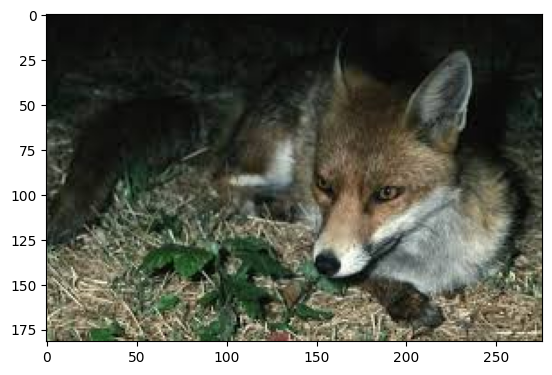

Output shape: torch.Size([1, 10])
Top probability: 0.7639
Predicted class: deer
Three top predictions:
deer: 0.7639
frog: 0.1212
horse: 0.0399
The predicted class for images_a.jpg is: deer

**********


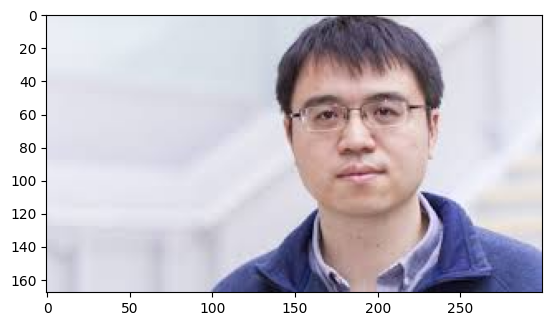

Output shape: torch.Size([1, 10])
Top probability: 0.3215
Predicted class: dog
Three top predictions:
dog: 0.3215
frog: 0.1755
bird: 0.1568
The predicted class for images_b.jpg is: dog

**********


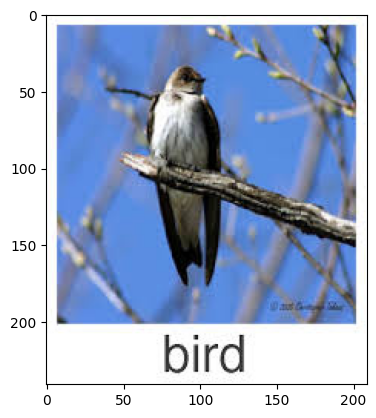

Output shape: torch.Size([1, 10])
Top probability: 0.3052
Predicted class: cat
Three top predictions:
cat: 0.3052
truck: 0.2620
automobile: 0.1829
The predicted class for images_c.jpg is: cat

**********


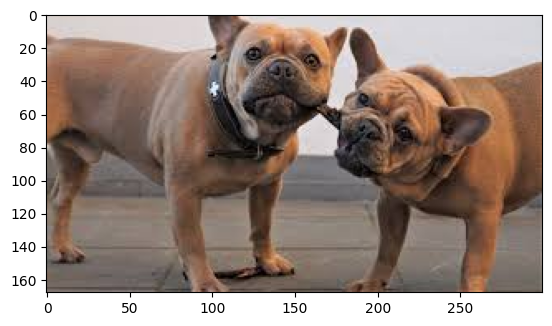

Output shape: torch.Size([1, 10])
Top probability: 0.9074
Predicted class: horse
Three top predictions:
horse: 0.9074
deer: 0.0770
cat: 0.0081
The predicted class for images_d.jpg is: horse

**********


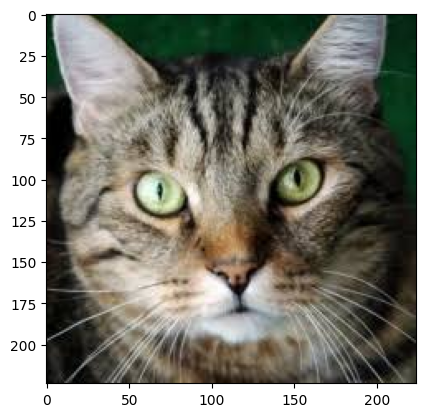

Output shape: torch.Size([1, 10])
Top probability: 0.2301
Predicted class: ship
Three top predictions:
ship: 0.2301
horse: 0.1641
bird: 0.1367
The predicted class for images_e.jpg is: ship

**********


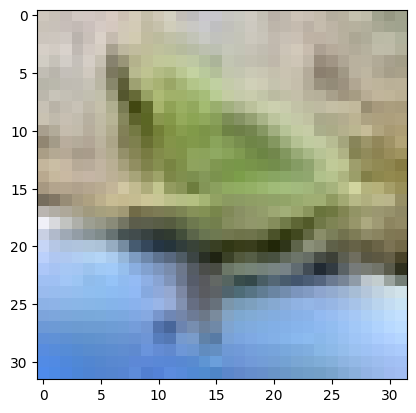

Output shape: torch.Size([1, 10])
Top probability: 0.2215
Predicted class: ship
Three top predictions:
ship: 0.2215
bird: 0.1829
horse: 0.1539
The predicted class for images_f.jpg is: ship

**********


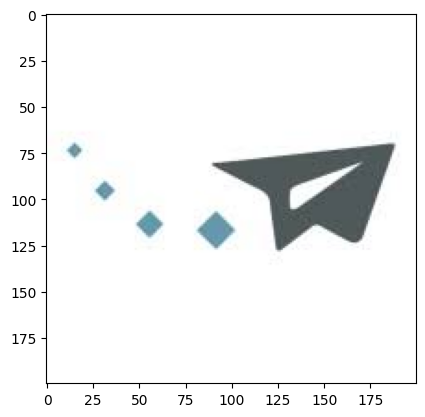

Output shape: torch.Size([1, 10])
Top probability: 0.5170
Predicted class: airplane
Three top predictions:
airplane: 0.5170
ship: 0.4385
automobile: 0.0269
The predicted class for images_g.jpg is: airplane

**********


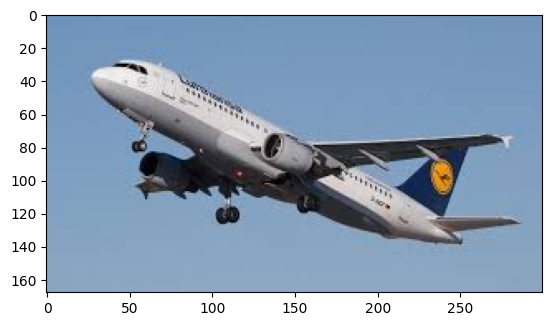

Output shape: torch.Size([1, 10])
Top probability: 0.9279
Predicted class: airplane
Three top predictions:
airplane: 0.9279
bird: 0.0319
cat: 0.0108
The predicted class for images_h.jpg is: airplane

**********


In [50]:
images = ['images_a.jpg', 'images_b.jpg', 'images_c.jpg', 'images_d.jpg', 'images_e.jpg', 'images_f.jpg', 'images_g.jpg', 'images_h.jpg']

for img_path in images:
    predicted_class = predict_image_class(img_path, model, class_names, device)
    print(f"The predicted class for {img_path} is: {predicted_class}\n")
    print('*'*10)

# What should be done for more accuracy?



For more accuracy, we can increase the number of epochs and also use data augmentation to increase the number of images in the dataset?